In [135]:
import pandas as pd
import numpy as np
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import RandomForestRegressor
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 20)
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
from scipy.stats import randint, uniform
import joblib
import csv

### Data Preprocessing

In [171]:
df = pd.read_csv("./datasets/new_raw.csv")
first = ["name", "nvar"]
df = df[first + [c for c in df.columns if c not in first]]
df["nvar"].value_counts
df = df.sort_values(["name", "nvar", "mem"]).reset_index()
df

,index,name,nvar,nvmops,objective,eval_duration_solver,extract_duration_solver,stats_elapsed_time,dual_feas,status,timed_bytes,timed_time,timed_gctime,nlp_warmup_time,mem,neval_grad,iter,source_solver,problem,neval_obj,timestamp_solver,error_solver,vector_type,extract_duration_problem,highest_degree (ExprTree),nln_nnzj,adbackend_hessian_backend_type,minimize,count_plus_minus,alloc_obj,jtprod_available,has_equalities,time_hprod,adbackend_jprod_residual_backend_type,adbackend_ghjvprod_backend_type,nnln,jprod_residual_available,nlvb,nlvo,nlp_type,unconstrained,adbackend_jacobian_backend_type,adbackend_jprod_backend_type,hprod_residual_available,jac_available,hess_residual_available,adbackend_gradient_backend_type,float_type,ncon,is_nls,nnzo,nlvc,tree_length,count_trigonometric_function,matrix_free,nlin,time_obj,tree_depth,is_constant (ExprTree),nnzj,alloc_hprod,adbackend_jacobian_residual_backend_type,generator,alloc_hess,hess_available,count_exponential_function,islp,count_op_function,error_problem,adbackend_hprod_residual_backend_type,equality_constrained,time_grad,source_problem,has_bounds,grad_available,clinvals_nnz,jac_residual_available,bound_constrained,jprod_available,eval_duration_problem,adbackend_hessian_residual_backend_type,nequ,adbackend_jtprod_residual_backend_type,has_inequalities,is_linear (ExprTree),linearly_constrained,adbackend_jtprod_backend_type,hprod_available,jtprod_residual_available,alloc_grad,inequality_constrained,time_hess,lin_nnzj,nnzh,timestamp_problem,adbackend_hprod_backend_type,error_type,total_alloc
0,15939,arglina,100,1.0,5.000000e+01,0.319062,0.011306,0.000135,7.841650e-15,first_order,18576.0,0.000164,0.000000,0.377710,1,4.0,1.0,OptimizationProb...,OptimizationProb...,4.0,2026-02-28 18:33...,NaN,Vector{Float64},4.309682,2.0,0.0,ADNLPModels.Empt...,1.0,305.0,34515160.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,10404.0,0.0,1.0,0.0,0.376715,9.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,0.0,509.0,NaN,ADNLPModels.Empt...,0.0,0.464686,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,1.980544,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,4.261110e+07,0.0,NaN,0.0,5.050000e+03,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,7.712626e+07
1,15940,arglina,100,1.0,5.000000e+01,0.319062,0.011309,0.000151,7.841650e-15,first_order,22120.0,0.000199,0.000000,0.377710,2,2.0,1.0,OptimizationProb...,OptimizationProb...,2.0,2026-02-28 18:33...,NaN,Vector{Float64},4.309682,2.0,0.0,ADNLPModels.Empt...,1.0,305.0,34515160.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,10404.0,0.0,1.0,0.0,0.376715,9.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,0.0,509.0,NaN,ADNLPModels.Empt...,0.0,0.464686,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,1.980544,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,4.261110e+07,0.0,NaN,0.0,5.050000e+03,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,7.712626e+07
2,15941,arglina,100,1.0,5.000000e+01,0.319062,0.011275,0.000140,7.841650e-15,first_order,25592.0,0.000182,0.000000,0.377710,3,2.0,1.0,OptimizationProb...,OptimizationProb...,2.0,2026-02-28 18:33...,NaN,Vector{Float64},4.309682,2.0,0.0,ADNLPModels.Empt...,1.0,305.0,34515160.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,10404.0,0.0,1.0,0.0,0.376715,9.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,0.0,509.0,NaN,ADNLPModels.Empt...,0.0,0.464686,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,1.980544,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModel

### Identity the features and targets for this model

In [172]:
feature_cols_reg = [
                    # Core Features
                    "nvar", 
                    "mem",
                    "tree_length", 
                    "tree_depth", 
                    "time_obj",  # initial eval
                    "time_grad",
                    "extract_duration_problem",
                    
                    # Expression Tree Features
                    "highest_degree (ExprTree)",
                    "count_plus_minus",
                    "count_trigonometric_function",
                    "count_exponential_function",
                    "count_op_function",

                    # allocation
                    "alloc_obj",
                    "alloc_grad",
                    "total_alloc",
                  ]

target_cols_reg = [ "neval_obj",
                    "neval_grad",
                    "timed_bytes"] #(neval_obj, neval_grad, timed_bytes)

target_col_model = ["stats_elapsed_time"]

group_key = ["name", "nvar"]                                                                                                                   # [...]     
all_cols = list(set(feature_cols_reg + target_cols_reg + target_col_model + group_key))
solver_metrics = ['neval_grad', 'neval_obj', 'timed_bytes']
df[solver_metrics] = df[solver_metrics].fillna(0)
df = df[all_cols]
df.isna().sum().sort_values(ascending=False)

nvar                            0
extract_duration_problem        0
highest_degree (ExprTree)       0
total_alloc                     0
count_trigonometric_function    0
neval_obj                       0
count_plus_minus                0
neval_grad                      0
alloc_grad                      0
time_grad                       0
tree_depth                      0
time_obj                        0
mem                             0
count_exponential_function      0
stats_elapsed_time              0
count_op_function               0
tree_length                     0
name                            0
alloc_obj                       0
timed_bytes                     0
dtype: int64

In [173]:
df = df.copy()
df["mem_count"] = df.groupby(["name", "nvar"]).transform('size')
df = df[df["mem_count"] == 100].copy().reset_index(drop=True)
df

,nvar,extract_duration_problem,alloc_obj,name,tree_length,count_op_function,stats_elapsed_time,count_exponential_function,mem,time_obj,tree_depth,time_grad,alloc_grad,neval_grad,count_plus_minus,neval_obj,count_trigonometric_function,total_alloc,highest_degree (ExprTree),timed_bytes,mem_count
0,100,4.309682,34515160.0,arglina,10404.0,509.0,0.000135,0.0,1,0.376715,9.0,0.464686,4.261110e+07,4.0,305.0,4.0,0.0,7.712626e+07,2.0,18576.0,100
1,100,4.309682,34515160.0,arglina,10404.0,509.0,0.000151,0.0,2,0.376715,9.0,0.464686,4.261110e+07,2.0,305.0,2.0,0.0,7.712626e+07,2.0,22120.0,100
2,100,4.309682,34515160.0,arglina,10404.0,509.0,0.000140,0.0,3,0.376715,9.0,0.464686,4.261110e+07,2.0,305.0,2.0,0.0,7.712626e+07,2.0,25592.0,100
3,100,4.309682,34515160.0,arglina,10404.0,509.0,0.000151,0.0,4,0.376715,9.0,0.464686,4.261110e+07,2.0,305.0,2.0,0.0,7.712626e+07,2.0,29128.0,100
4,100,4.309682,34515160.0,arglina,10404.0,509.0,0.000139,0.0,5,0.376715,9.0,0.464686,4.261110e+07,2.0,305.0,2.0,0.0,7.712626e+07,2.0,32600.0,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21495,100000,2813.283680,65309368.0,woods,425000.0,575001.0,1279.820757,0.0,96,0.073713,7.0,35.399378,2.573195e+10,59.0,275001.0,68.0,0.0,2.579726e+10,2.0,314448744.0,100
21496,100000,2813.283680,65309368.0,woods,425000.0,575001.0,1112.816634,0.0,97,0.073713,7.0,35.399378,2.573195e+10,59.0,275001.0,68.0,0.0,2.579726e+10,2.0,317646328.0,100
21497,100000,2813.283680,65309368.0,woods,425000.0,575001.0,1162.156092,0.0,98,0.073713,7.0,35.399378,2.573195e+10,59.0,275001.0,68.0,0.0,2.579726e+10,2.0,320848008.0,100
21498,100000,2813.283680,65309368.0,woods,425000.0,575001.0,1396.521273,0.0,99,0.073713,7.0,35.399378,2.573195e+10,59.0,275001.0,68.0,0.0,2.579726e+10,2.0,324045592.0,100


In [174]:
# unique instances: one row per (problem, nvar)
instances = df[group_key].drop_duplicates()

# shuffle instances
instances = instances.sample(frac=1, random_state=66).reset_index(drop=True)

n = len(instances)
n_train = int(0.8 * n)

train_inst = instances.iloc[:n_train]
test_inst  = instances.iloc[n_train :]

# assign rows to splits by (problem, nvar)
train_df = df.merge(train_inst, on=["nvar", "name"], how="inner").reset_index(drop=True)
test_df  = df.merge(test_inst,  on=["nvar", "name"], how="inner").reset_index(drop=True)
all_df = pd.concat([train_df, test_df], axis=0)
all_df = all_df.reset_index(drop=True)
all_df

,nvar,extract_duration_problem,alloc_obj,name,tree_length,count_op_function,stats_elapsed_time,count_exponential_function,mem,time_obj,tree_depth,time_grad,alloc_grad,neval_grad,count_plus_minus,neval_obj,count_trigonometric_function,total_alloc,highest_degree (ExprTree),timed_bytes,mem_count
0,100,4.309682,34515160.0,arglina,10404.0,509.0,0.000135,0.0,1,0.376715,9.0,0.464686,42611104.0,4.0,305.0,4.0,0.0,77126264.0,2.0,18576.0,100
1,100,4.309682,34515160.0,arglina,10404.0,509.0,0.000151,0.0,2,0.376715,9.0,0.464686,42611104.0,2.0,305.0,2.0,0.0,77126264.0,2.0,22120.0,100
2,100,4.309682,34515160.0,arglina,10404.0,509.0,0.000140,0.0,3,0.376715,9.0,0.464686,42611104.0,2.0,305.0,2.0,0.0,77126264.0,2.0,25592.0,100
3,100,4.309682,34515160.0,arglina,10404.0,509.0,0.000151,0.0,4,0.376715,9.0,0.464686,42611104.0,2.0,305.0,2.0,0.0,77126264.0,2.0,29128.0,100
4,100,4.309682,34515160.0,arglina,10404.0,509.0,0.000139,0.0,5,0.376715,9.0,0.464686,42611104.0,2.0,305.0,2.0,0.0,77126264.0,2.0,32600.0,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21495,10000,74.643566,75185144.0,woods,42500.0,57501.0,7.757891,0.0,96,0.113105,7.0,1.054803,471227304.0,59.0,27501.0,68.0,0.0,546412448.0,2.0,31484720.0,100
21496,10000,74.643566,75185144.0,woods,42500.0,57501.0,7.755893,0.0,97,0.113105,7.0,1.054803,471227304.0,59.0,27501.0,68.0,0.0,546412448.0,2.0,31804864.0,100
21497,10000,74.643566,75185144.0,woods,42500.0,57501.0,7.753765,0.0,98,0.113105,7.0,1.054803,471227304.0,59.0,27501.0,68.0,0.0,546412448.0,2.0,32125008.0,100
21498,10000,74.643566,75185144.0,woods,42500.0,57501.0,7.755922,0.0,99,0.113105,7.0,1.054803,471227304.0,59.0,27501.0,68.0,0.0,546412448.0,2.0,32445152.0,100


In [175]:
 # confirm and use the three predicted feature to predict time                                                                                                              #  
X_train = train_df[feature_cols_reg].to_numpy(dtype=float)
X_test  = test_df[feature_cols_reg].to_numpy(dtype=float)

y_train = np.log1p(train_df[target_cols_reg].to_numpy(dtype=float))
y_test  = np.log1p(test_df[target_cols_reg].to_numpy(dtype=float))

X_all = np.concatenate([X_train, X_test], axis=0)


In [176]:
X_train_time = train_df[target_cols_reg]
X_test_time = test_df[target_cols_reg]
y_train_time = np.log1p(train_df[target_col_model].to_numpy(dtype=float)).ravel()
y_test_time = np.log1p(test_df[target_col_model].to_numpy(dtype=float)).ravel()

### Global Performance Ratio Function

In [144]:
import numpy as np
import pandas as pd
from scipy.stats import gmean

def evaluate_model(model, label="Model"):
    """
    Evaluates a stage-2 model using global X_test_time and global test_df.
    Includes arithmetic mean, geometric mean, and maximum performance ratio metrics.
    """
    predictions = model.predict(X_test_time)
    working_df = test_df.copy() 
    
    working_df["predicted_time"] = predictions
    group_cols = ["name", "nvar"]

    # 1. Model Selection
    model_choices = (
        working_df.sort_values(by=group_cols + ["predicted_time", "mem"], ascending=[True, True, True, False])
        .groupby(group_cols).first().reset_index()
        [group_cols + ["mem", "predicted_time", "stats_elapsed_time"]]
        .rename(columns={"mem": "predicted_mem", "stats_elapsed_time": "actual_time"})
    )

    # 2. Oracle Selection
    oracle_choices = (
        working_df.sort_values(by=group_cols + ["stats_elapsed_time", "mem"], ascending=[True, True, True, False])
        .groupby(group_cols).first().reset_index()
        [group_cols + ["mem", "stats_elapsed_time"]]
        .rename(columns={"mem": "best_mem", "stats_elapsed_time": "best_time"})
    )

    # 3. Merge Matrix & Apply Hardened 0.10s Absolute Tolerance Filter
    final_df = pd.merge(model_choices, oracle_choices, on=group_cols).copy()
    final_df['actual_time'] = pd.to_numeric(final_df['actual_time'], errors='coerce')
    final_df['best_time'] = pd.to_numeric(final_df['best_time'], errors='coerce')

    final_df['raw_ratio'] = final_df['actual_time'] / final_df['best_time']
    time_diff = np.abs(final_df['actual_time'] - final_df['best_time'])
    final_df['performance_ratio'] = np.where(time_diff <= 0.10, 1.0, final_df['raw_ratio'])

    # Reorder display columns
    column_order = group_cols + ["predicted_mem", "predicted_time", "actual_time", "best_mem", "best_time", "performance_ratio", "raw_ratio"]
    final_df = final_df[column_order]

    # Output Summary Blocks
    print("\n" + "="*145)
    print(f"PER-PROBLEM PERFORMANCE PROFILE SUMMARY ({label.upper()})")
    print("="*145)
    print(final_df.to_string(index=False, formatters={
        'predicted_time': '{:.4f}'.format, 'actual_time': '{:.4f}'.format,
        'best_time': '{:.4f}'.format, 'performance_ratio': '{:.4f}'.format, 'raw_ratio': '{:.4f}'.format
    }))
    print("="*145)

    total_actual = final_df['actual_time'].sum()
    total_best = final_df['best_time'].sum()
    
    # Calculate Core Evaluation Statistics
    global_mean_ratio = final_df['performance_ratio'].mean()
    geom_mean_ratio = gmean(final_df['performance_ratio'])  # Clean Scipy implementation
    max_performance_ratio = final_df['performance_ratio'].max()
    
    print("\n" + "="*50)
    print(f"AGGREGATE METRICS ({label.upper()})")
    print("="*50)
    print(final_df['performance_ratio'].quantile([0.50, 0.75, 0.90]).to_string(float_format='{:.4f}'.format))
    print("-"*50)
    print(f"Global Mean Perf. Ratio     : {global_mean_ratio:.4f}")
    print(f"Geometric Mean Perf. Ratio  : {geom_mean_ratio:.4f}")
    print(f"Maximum Performance Ratio   : {max_performance_ratio:.4f}")
    print("-"*50)
    print(f"Total Actual Compute Time   : {total_actual:.4f}s")
    print(f"Total Oracle Optimal Time   : {total_best:.4f}s")
    print("="*50)
    
    return final_df

### Model selections and hyperparameter tunings of the model

### Best Model: MultiOutputRegressor wrapper with ExtraTreesRegressor (Extremely Randomized Trees)

In [7]:
# from sklearn.ensemble import GradientBoostingRegressor
# from sklearn.multioutput import MultiOutputRegressor
# from sklearn.metrics import mean_squared_error, r2_score

# best_model = MultiOutputRegressor(
#     ExtraTreesRegressor(n_estimators=300, max_depth=10, min_samples_leaf = 5, random_state=123, n_jobs=-1)
#     # TRY random forest 
# )
# best_model.fit(X_train, y_train)
# y_pred = best_model.predict(X_valid)
# print(f"Best model MSE={mean_squared_error(y_valid, y_pred):.4f}  R²={r2_score(y_valid, y_pred):.4f}")

### Random forest 

In [ ]:
# param_distributions = {
#     # Reduced max from 1500 to 500 (plenty for your 400 rows)
#     'n_estimators': randint(50, 500),
#     'max_depth': [None, 5, 10, 20, 30],
#     'min_samples_split': randint(5, 50),
#     'min_samples_leaf': randint(5, 25),
#     'criterion': ['squared_error', 'friedman_mse', 'poisson'],
    
#     'max_features': ['sqrt', 'log2'] + list(np.linspace(0.1, 0.9, 10)),
#     'bootstrap': [True],
#     'min_impurity_decrease': uniform(0, 0.05),
#     'ccp_alpha': uniform(0, 0.05)
# }

# rf = RandomForestRegressor(random_state=42, n_jobs=1)

# random_search = RandomizedSearchCV(
#     rf,
#     param_distributions=param_distributions,
#     n_iter=200,     
#     cv=5,      
#     scoring='neg_mean_squared_error',
#     n_jobs=4,          
#     random_state=42,
#     verbose=3           
# )

# random_search.fit(X_train, y_train)

# # Results
# print("\n" + "="*80)
# print("BEST RESULTS")
# print("="*80)
# print("Best parameters:", random_search.best_params_)
# print("Best CV score (neg MSE):", random_search.best_score_)
# print("Actual MSE:", -random_search.best_score_)

# # Save detailed results
# results_df = pd.DataFrame(random_search.cv_results_)
# results_df['actual_mse'] = -results_df['mean_test_score']
# results_df = results_df.sort_values('actual_mse')

# # Top 20 configurations
# print("\n" + "="*80)
# print("TOP 20 CONFIGURATIONS")
# print("="*80)
# top_cols = ['mean_test_score', 'std_test_score', 'mean_fit_time', 
#             'param_n_estimators', 'param_max_depth', 'param_max_features',
#             'param_min_samples_split', 'param_min_samples_leaf']
# print(results_df[top_cols].head(20).to_string())

# # Save to CSV
# results_df.to_csv('rf_randomsearch_comprehensive_results.csv', index=False)
# print(f"\nFull results saved to rf_randomsearch_comprehensive_results.csv")

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
[CV 1/5] END bootstrap=True, ccp_alpha=0.018727005942368126, criterion=squared_error, max_depth=10, max_features=0.5444444444444445, min_impurity_decrease=0.02993292420985183, min_samples_leaf=11, min_samples_split=23, n_estimators=264;, score=-5.806 total time=   1.6s
[CV 4/5] END bootstrap=True, ccp_alpha=0.018727005942368126, criterion=squared_error, max_depth=10, max_features=0.5444444444444445, min_impurity_decrease=0.02993292420985183, min_samples_leaf=11, min_samples_split=23, n_estimators=264;, score=-2.967 total time=   1.6s
[CV 2/5] END bootstrap=True, ccp_alpha=0.018727005942368126, criterion=squared_error, max_depth=10, max_features=0.5444444444444445, min_impurity_decrease=0.02993292420985183, min_samples_leaf=11, min_samples_split=23, n_estimators=264;, score=-5.458 total time=   1.7s
[CV 3/5] END bootstrap=True, ccp_alpha=0.018727005942368126, criterion=squared_error, max_depth=10, max_features=0.54444444444

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



BEST RESULTS
Best parameters: {'bootstrap': True, 'ccp_alpha': 0.004206998249752442, 'criterion': 'friedman_mse', 'max_depth': 20, 'max_features': 0.1, 'min_impurity_decrease': 0.018614138328087153, 'min_samples_leaf': 7, 'min_samples_split': 29, 'n_estimators': 398}
Best CV score (neg MSE): -3.1481259171361042
Actual MSE: 3.1481259171361042

TOP 20 CONFIGURATIONS
     mean_test_score  std_test_score  mean_fit_time  param_n_estimators param_max_depth param_max_features  param_min_samples_split  param_min_samples_leaf
33         -3.148126        0.947813       1.840966                 398              20                0.1                       29                       7
35         -3.191466        0.927228       1.397984                 244              30           0.188889                       11                      12
6          -3.198744        0.918119       4.016469                 469              20           0.544444                       21                      18
134     

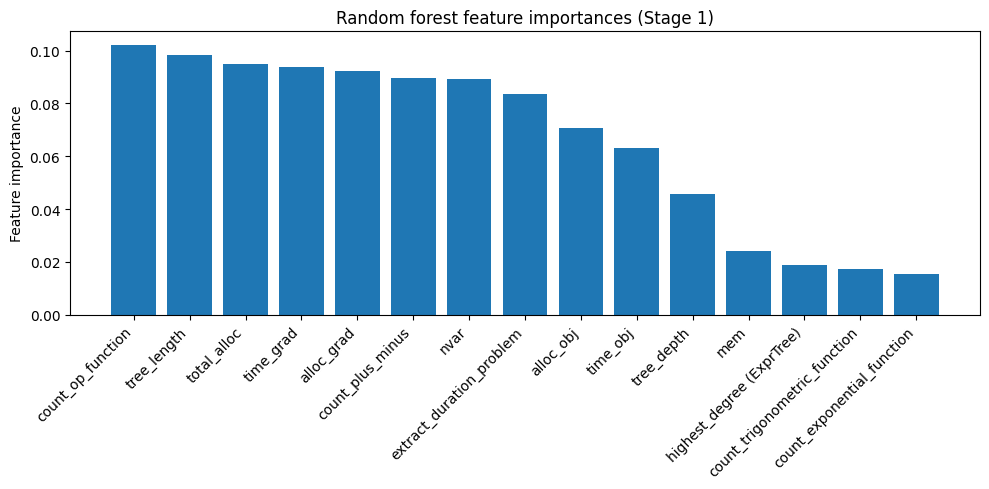

In [177]:
import numpy as np
import matplotlib.pyplot as plt

best_model = joblib.load('./model_weights/best_rf_model_reg.pkl')
# best_model = random_search.best_estimator_
rf_importances = best_model.feature_importances_
indices_rf = np.argsort(rf_importances)[::-1]  

plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_cols_reg)), rf_importances[indices_rf])
plt.xticks(range(len(feature_cols_reg)), [feature_cols_reg[i] for i in indices_rf], rotation=45, ha="right")
plt.ylabel("Feature importance")
plt.title("Random forest feature importances (Stage 1)")
plt.tight_layout()
plt.show()

# joblib.dump(best_model, './model_weights/best_rf_model_reg.pkl')

In [178]:
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

pred = best_model.predict(X_test)

# multioutput='raw_values' returns an array of metrics, one per target
test_mse_per_target = mean_squared_error(y_test, pred, multioutput='raw_values')
test_r2_per_target  = r2_score(y_test, pred, multioutput='raw_values')

# Loop through each target column to print its specific MSE and R²
for i, col in enumerate(target_cols_reg):
    print(f"\nTarget: {col}")
    print(f"  MSE: {test_mse_per_target[i]:.4f}")
    print(f"  R²:  {test_r2_per_target[i]:.4f}")

# Quantiled Relative Error Distribution
relative_error = np.abs(pred - y_test) / (np.abs(y_test) + 1e-8)

quantiles = [0.25, 0.50, 0.75]
print("\n--- Quantiled Relative Error Q(q) (Test Set) ---")
for i, col in enumerate(target_cols_reg):
    print(f"\n{col}:")
    print(f"Quantile (q) | Relative Error Value Q(q)")
    
    # Compute the error magnitudes at each specific quantile marker
    q_values = np.quantile(relative_error[:, i], quantiles)
    
    for q, val in zip(quantiles, q_values):
        print(f"  Q({q:.2f}):  {val:.4f}")


Target: neval_obj
  MSE: 1.6363
  R²:  0.4316

Target: neval_grad
  MSE: 1.9272
  R²:  0.4376

Target: timed_bytes
  MSE: 0.5808
  R²:  0.8453

--- Quantiled Relative Error Q(q) (Test Set) ---

neval_obj:
Quantile (q) | Relative Error Value Q(q)
  Q(0.25):  0.0442
  Q(0.50):  0.1671
  Q(0.75):  0.3231

neval_grad:
Quantile (q) | Relative Error Value Q(q)
  Q(0.25):  0.0535
  Q(0.50):  0.1818
  Q(0.75):  0.3351

timed_bytes:
Quantile (q) | Relative Error Value Q(q)
  Q(0.25):  0.0140
  Q(0.50):  0.0287
  Q(0.75):  0.0530


### Using the predicted value of ["neval_obj", "neval_grad", "timed_bytes"] to predict time

In [179]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_predict

# 1. Define your log-space targets for Stage 2 (Actual Time)
y_train_time = np.log1p(train_df[target_col_model].to_numpy(dtype=float)).ravel()
y_test_time  = np.log1p(test_df[target_col_model].to_numpy(dtype=float)).ravel()

# 2. CROSS-VALIDATION: Generate realistic, noisy 3-column features for Stage 2
X_train_time = pd.DataFrame(
    cross_val_predict(best_model, X_train, y_train, cv=5, n_jobs=-1),
    columns=target_cols_reg
)

# 3. Fit the Stage 1 model on the full training set to learn the 3 metrics
best_model.fit(X_train, y_train)

# 4. Generate standard 3-column test features for Stage 2
X_test_time = pd.DataFrame(
    best_model.predict(X_test),
    columns=target_cols_reg
)

In [ ]:
# param_distributions = {
#     'n_estimators': randint(50, 500),
#     'max_depth': [None, 5, 10, 20, 30, 50],
#     'min_samples_split': randint(5, 50),
#     'min_samples_leaf': randint(2, 20),
#     'max_features': ['sqrt', 'log2', 0.5, 0.7],
#     'bootstrap': [True],
#     'min_impurity_decrease': uniform(0, 0.05),
#     'ccp_alpha': uniform(0, 0.05),
#     'criterion': ['squared_error', 'friedman_mse', 'poisson']
# }

# rf = RandomForestRegressor(random_state=42, n_jobs=1)

# time_random_search = RandomizedSearchCV(
#     rf,
#     param_distributions=param_distributions,
#     n_iter=200,
#     cv=5,
#     scoring='neg_mean_squared_error',
#     n_jobs=4,
#     random_state=42,
#     verbose=3,
#     return_train_score=True,
#     error_score='raise'
# )

# time_random_search.fit(X_train_time, y_train_time)

# print("\n" + "="*80)
# print("BEST RESULTS")
# print("="*80)
# print("Best parameters:", time_random_search.best_params_)
# print("Best CV score (neg MSE):", time_random_search.best_score_)
# print("Actual MSE:", -time_random_search.best_score_)

# results_df = pd.DataFrame(time_random_search.cv_results_)
# results_df['actual_mse'] = -results_df['mean_test_score']
# results_df = results_df.sort_values('actual_mse')

# print("\n" + "="*80)
# print("TOP 20 CONFIGURATIONS")
# print("="*80)
# top_cols = ['mean_test_score', 'std_test_score', 'mean_fit_time', 
#             'param_n_estimators', 'param_max_depth', 'param_max_features',
#             'param_min_samples_split', 'param_min_samples_leaf']
# print(results_df[top_cols].head(20).to_string())

# results_df.to_csv('rf_randomsearch_comprehensive_results.csv', index=False)


Fitting 5 folds for each of 200 candidates, totalling 1000 fits
[CV 2/5] END bootstrap=True, ccp_alpha=0.018727005942368126, criterion=squared_error, max_depth=10, max_features=0.7, min_impurity_decrease=0.02993292420985183, min_samples_leaf=8, min_samples_split=23, n_estimators=264;, score=(train=-1.083, test=-2.746) total time=   1.7s
[CV 1/5] END bootstrap=True, ccp_alpha=0.018727005942368126, criterion=squared_error, max_depth=10, max_features=0.7, min_impurity_decrease=0.02993292420985183, min_samples_leaf=8, min_samples_split=23, n_estimators=264;, score=(train=-0.893, test=-1.903) total time=   1.8s
[CV 4/5] END bootstrap=True, ccp_alpha=0.018727005942368126, criterion=squared_error, max_depth=10, max_features=0.7, min_impurity_decrease=0.02993292420985183, min_samples_leaf=8, min_samples_split=23, n_estimators=264;, score=(train=-0.975, test=-1.408) total time=   1.9s
[CV 3/5] END bootstrap=True, ccp_alpha=0.018727005942368126, criterion=squared_error, max_depth=10, max_feature

In [180]:
time_best_model = joblib.load('./model_weights/best_rf_model_time.pkl')
# time_best_model = time_random_search.best_estimator_
accuracy = time_best_model.score(X_test_time, y_test_time)
print(f"Time prediction accuracy based on predicted values={accuracy}")

# joblib.dump(time_best_model, './model_weights/best_rf_model_time.pkl')

Time prediction accuracy based on predicted values=0.527973689717826


In [181]:
time_best_model = joblib.load('./model_weights/best_rf_model_time.pkl')
accuracy = time_best_model.score(X_test_time, y_test_time)
print(f"Time prediction accuracy based on predicted values={accuracy}")

pred = time_best_model.predict(X_test_time)
test_mse = mean_squared_error(y_test_time, pred)
test_r2  = r2_score(y_test_time, pred)
print(f"MSE={test_mse:.4f}  R²={test_r2:.4f}")

# Compute pointwise relative error matching the paper's formula: |y - y_hat| / (|y| + delta)
relative_error = np.abs(pred - y_test_time) / (np.abs(y_test_time) + 1e-8)

# Quantiled Relative Error Distribution
quantiles = [0.25, 0.50, 0.75]
print("\n--- Quantiled Relative Error Q(q) (Test Set) ---")
for i, col in enumerate(target_col_model):
    print(f"\n{col}:")
    print(f"Quantile (q) | Relative Error Value Q(q)")
    
    # Safe extraction whether relative_error is a 1D vector or a 2D column matrix
    error_data = relative_error[:, i] if relative_error.ndim > 1 else relative_error
    q_values = np.quantile(error_data, quantiles)
    
    for q, val in zip(quantiles, q_values):
        print(f"  Q({q:.2f}):  {val:.4f}")

Time prediction accuracy based on predicted values=0.527973689717826
MSE=2.1318  R²=0.5280

--- Quantiled Relative Error Q(q) (Test Set) ---

stats_elapsed_time:
Quantile (q) | Relative Error Value Q(q)
  Q(0.25):  0.3616
  Q(0.50):  0.7705
  Q(0.75):  13.1762


In [155]:
evaluate_model(time_best_model, label="Stage 2 Random Forest")


PER-PROBLEM PERFORMANCE PROFILE SUMMARY (STAGE 2 RANDOM FOREST)
        name   nvar  predicted_mem predicted_time actual_time  best_mem best_time performance_ratio raw_ratio
     arglinb    100             16         0.2057      0.0004         1    0.0002            1.0000    1.7958
     argtrig    100             96         0.1922      0.0160        61    0.0081            1.0000    1.9750
     arwhead   1000             15         0.4485      0.0458         3    0.0401            1.0000    1.1435
     brownal    100              1         0.2057      0.0003         1    0.0003            1.0000    1.0000
      brybnd  10000              1         3.5827     23.0197         1   23.0197            1.0000    1.0000
    clplatea    961              3         0.3645      4.1646        97    1.0576            3.9377    3.9377
    clplatec    100            100         0.2092      0.0208        87    0.0129            1.0000    1.6133
      cosine    100             38         0.2117      

,name,nvar,predicted_mem,predicted_time,actual_time,best_mem,best_time,performance_ratio,raw_ratio
0,arglinb,100,16,0.205653,0.000411,1,0.000229,1.000000,1.795833
1,argtrig,100,96,0.192190,0.016049,61,0.008126,1.000000,1.975002
2,arwhead,1000,15,0.448469,0.045813,3,0.040062,1.000000,1.143549
3,brownal,100,1,0.205653,0.000280,1,0.000280,1.000000,1.000000
4,brybnd,10000,1,3.582717,23.019709,1,23.019709,1.000000,1.000000
5,clplatea,961,3,0.364468,4.164609,97,1.057629,3.937685,3.937685
6,clplatec,100,100,0.209210,0.020761,87,0.012869,1.000000,1.613273
7,cosine,100,38,0.211749,0.001025,1,0.000634,1.000000,1.616773
8,cragglvy,1000,1,0.192190,0.415430,12,0.247496,1.678532,1.678532
9,cragglvy,10000,3,3.025772,27.082774,6,24.499405,1.105446,1.105446


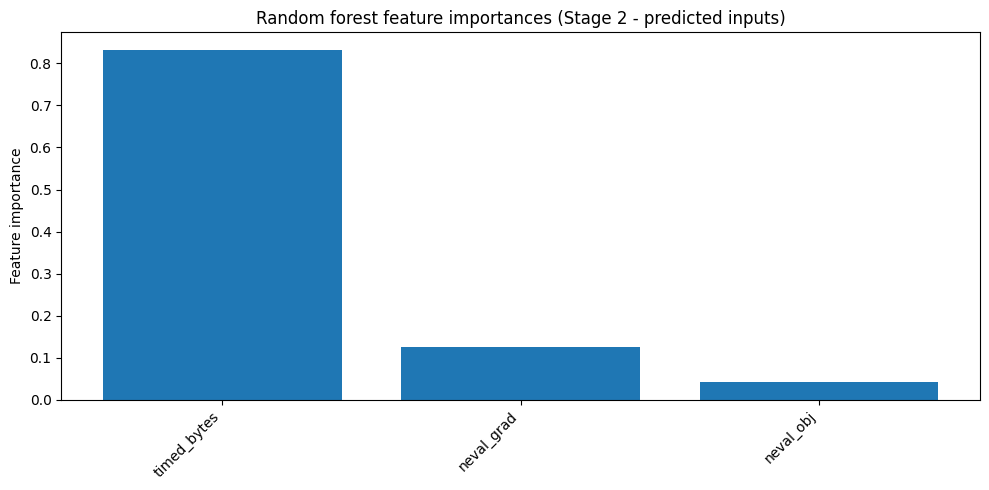

In [182]:
best_model_time = time_best_model
rf_importances = best_model_time.feature_importances_
indices_rf = np.argsort(rf_importances)[::-1]  

plt.figure(figsize=(10, 5))
plt.bar(range(len(target_cols_reg)), rf_importances[indices_rf])
plt.xticks(range(len(target_cols_reg)), [target_cols_reg[i] for i in indices_rf], rotation=45, ha="right")
plt.ylabel("Feature importance")
plt.title("Random forest feature importances (Stage 2 - predicted inputs)")
plt.tight_layout()
plt.show()

### Using the actual value of ["neval_obj", "neval_grad", "timed_bytes"] to predict time

In [184]:
X_train_time = train_df[target_cols_reg]
X_test_time = test_df[target_cols_reg]
y_train_time = np.log1p(train_df[target_col_model].to_numpy(dtype=float)).ravel()
y_test_time = np.log1p(test_df[target_col_model].to_numpy(dtype=float)).ravel()

In [161]:
# import pandas as pd
# import numpy as np
# import os
# import joblib
# from scipy.stats import randint, uniform
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.model_selection import RandomizedSearchCV, KFold, cross_validate

# # 1. Define Continuous and Discrete Distributions
# # Using continuous distributions allows the search to find highly specific optimal values
# param_distributions = {
#     'n_estimators': randint(100, 1000),
#     'max_depth': [10, 20, 30, 40, 50, None],
#     'min_samples_split': randint(2, 20),
#     'min_samples_leaf': randint(1, 10),
#     'max_features': uniform(0.1, 0.9), # Explores any fraction between 10% and 100%
#     'bootstrap': [True, False]
# }

# # 2. Initialize Base Estimator
# rf = RandomForestRegressor(random_state=42, n_jobs=1)

# # 3. Configure Nested Cross-Validation
# inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)
# outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# # 4. Set up Randomized Search (Inner Loop)
# # 500 iterations provide excellent coverage of the parameter space without the 96,000 fits of a grid
# random_search = RandomizedSearchCV(
#     estimator=rf,
#     param_distributions=param_distributions,
#     n_iter=500, 
#     cv=inner_cv,
#     scoring='neg_mean_squared_error',
#     n_jobs=5, # Utilizing your 10 cores
#     random_state=42,
#     verbose=1,
#     return_train_score=True,
#     error_score='raise'
# )

# print("\n" + "="*80)
# print("STARTING NESTED CROSS-VALIDATION (UNBIASED EVALUATION)")
# print("="*80)

# # 5. Execute Outer Loop to prove the model does not overfit
# nested_cv_results = cross_validate(
#     random_search, 
#     X=X_train_time, 
#     y=y_train_time, 
#     cv=outer_cv, 
#     scoring=['neg_mean_squared_error', 'r2'],
#     n_jobs=1, 
#     return_train_score=True
# )

# nested_test_mse = -nested_cv_results['test_neg_mean_squared_error']
# nested_train_mse = -nested_cv_results['train_neg_mean_squared_error']

# print(f"Nested CV Test MSE: {nested_test_mse.mean():.4f} (std: {nested_test_mse.std():.4f})")
# print(f"Nested CV Train MSE: {nested_train_mse.mean():.4f} (std: {nested_train_mse.std():.4f})")
# print(f"Nested CV Test R2: {nested_cv_results['test_r2'].mean():.4f}")

# print("\n" + "="*80)
# print("STARTING FULL RANDOMIZED SEARCH FOR FINAL MODEL PRODUCTION")
# print("="*80)

# # 6. Fit final model on all training data
# random_search.fit(X_train_time, y_train_time)

# # 7. Evaluate on the hold-out test set
# best_model_stage2 = random_search.best_estimator_
# accuracy = best_model_stage2.score(X_test_time, y_test_time)
# print(f"\nTime prediction accuracy (R^2) on hold-out test set = {accuracy:.4f}")

# # 8. Save Artifacts
# os.makedirs('./model_weights', exist_ok=True)
# model_path = './model_weights/best_rf_stage2_comprehensive.pkl'
# joblib.dump(best_model_stage2, model_path)

# results_df = pd.DataFrame(random_search.cv_results_)
# results_df['actual_test_mse'] = -results_df['mean_test_score']
# results_df['actual_train_mse'] = -results_df['mean_train_score']
# results_df = results_df.sort_values('actual_test_mse')
# results_df.to_csv('rf_randomized_search_results.csv', index=False)

# print(f"\nModel successfully saved to {model_path}")
# print("Detailed CV results exported to 'rf_randomized_search_results.csv'")

In [159]:
time_best_model_stage2_comp = joblib.load('./model_weights/best_rf_stage2_comprehensive.pkl')
accuracy = time_best_model_stage2_comp.score(X_test_time, y_test_time)
print(f"Time prediction accuracy based on predicted values={accuracy}")

pred = time_best_model_stage2_comp.predict(X_test_time)
test_mse = mean_squared_error(y_test_time, pred)
test_r2  = r2_score(y_test_time, pred)
print(f"MSE={test_mse:.4f}  R²={test_r2:.4f}")

# Compute pointwise relative error matching the paper's formula: |y - y_hat| / (|y| + delta)
relative_error = np.abs(pred - y_test_time) / (np.abs(y_test_time) + 1e-8)

# Quantiled Relative Error Distribution
quantiles = [0.25, 0.50, 0.75]
print("\n--- Quantiled Relative Error Q(q) (Test Set) ---")
for i, col in enumerate(target_col_model):
    print(f"\n{col}:")
    print(f"Quantile (q) | Relative Error Value Q(q)")
    
    # Safe extraction whether relative_error is a 1D vector or a 2D column matrix
    error_data = relative_error[:, i] if relative_error.ndim > 1 else relative_error
    q_values = np.quantile(error_data, quantiles)
    
    for q, val in zip(quantiles, q_values):
        print(f"  Q({q:.2f}):  {val:.4f}")

Time prediction accuracy based on predicted values=0.5548425872897635
MSE=2.0105  R²=0.5548

--- Quantiled Relative Error Q(q) (Test Set) ---

stats_elapsed_time:
Quantile (q) | Relative Error Value Q(q)
  Q(0.25):  0.1987
  Q(0.50):  0.6472
  Q(0.75):  3.8890


In [165]:
# evaluate_model(joblib.load('./model_weights/best_rf_stage2_comprehensive.pkl'))

In [185]:
time_best_model_raw = joblib.load('./model_weights/best_rf_model_time_raw.pkl')
# time_best_model_raw = time_random_search_raw.best_estimator_
accuracy = time_best_model_raw.score(X_test_time, y_test_time)
print(f"Time prediction accuracy based on predicted values={accuracy}")

joblib.dump(time_best_model_raw, './model_weights/best_rf_model_time_raw.pkl')

Time prediction accuracy based on predicted values=0.747420843621583


['./model_weights/best_rf_model_time_raw.pkl']

In [186]:
pred = time_best_model_raw.predict(X_test_time)
test_mse = mean_squared_error(y_test_time, pred)
test_r2  = r2_score(y_test_time, pred)
print(f"MSE={test_mse:.4f}  R²={test_r2:.4f}")

# Compute pointwise relative error matching the paper's formula: |y - y_hat| / (|y| + delta)
relative_error = np.abs(pred - y_test_time) / (np.abs(y_test_time) + 1e-8)

# Quantiled Relative Error Distribution
quantiles = [0.25, 0.50, 0.75]
print("\n--- Quantiled Relative Error Q(q) (Test Set) ---")
for i, col in enumerate(target_col_model):
    print(f"\n{col}:")
    print(f"Quantile (q) | Relative Error Value Q(q)")
    
    # Safe extraction whether relative_error is a 1D vector or a 2D column matrix
    error_data = relative_error[:, i] if relative_error.ndim > 1 else relative_error
    q_values = np.quantile(error_data, quantiles)
    
    for q, val in zip(quantiles, q_values):
        print(f"  Q({q:.2f}):  {val:.4f}")

MSE=1.1407  R²=0.7474

--- Quantiled Relative Error Q(q) (Test Set) ---

stats_elapsed_time:
Quantile (q) | Relative Error Value Q(q)
  Q(0.25):  0.2837
  Q(0.50):  0.8511
  Q(0.75):  8.5274


In [164]:
evaluate_model(joblib.load('./model_weights/best_rf_model_time_raw.pkl'))


PER-PROBLEM PERFORMANCE PROFILE SUMMARY (MODEL)
        name   nvar  predicted_mem predicted_time actual_time  best_mem best_time performance_ratio raw_ratio
     arglinb    100            100         0.0524      0.0003         1    0.0002            1.0000    1.2667
     argtrig    100             23         0.1773      0.0101        61    0.0081            1.0000    1.2454
     arwhead   1000              7         0.0693      0.0485         3    0.0401            1.0000    1.2095
     brownal    100              1         0.1332      0.0003         1    0.0003            1.0000    1.0000
      brybnd  10000              2         1.7650     25.7393         1   23.0197            1.1181    1.1181
    clplatea    961              2         0.3261      4.5787        97    1.0576            4.3292    4.3292
    clplatec    100             96         0.1765      0.0144        87    0.0129            1.0000    1.1193
      cosine    100              1         0.1535      0.0006         1

,name,nvar,predicted_mem,predicted_time,actual_time,best_mem,best_time,performance_ratio,raw_ratio
0,arglinb,100,100,0.052422,0.000290,1,0.000229,1.000000,1.266667
1,argtrig,100,23,0.177290,0.010120,61,0.008126,1.000000,1.245372
2,arwhead,1000,7,0.069255,0.048455,3,0.040062,1.000000,1.209495
3,brownal,100,1,0.133161,0.000280,1,0.000280,1.000000,1.000000
4,brybnd,10000,2,1.764957,25.739328,1,23.019709,1.118143,1.118143
5,clplatea,961,2,0.326112,4.578721,97,1.057629,4.329232,4.329232
6,clplatec,100,96,0.176461,0.014404,87,0.012869,1.000000,1.119275
7,cosine,100,1,0.153475,0.000634,1,0.000634,1.000000,1.000000
8,cragglvy,1000,5,0.076363,0.302003,12,0.247496,1.000000,1.220234
9,cragglvy,10000,2,0.292743,28.793137,6,24.499405,1.175259,1.175259


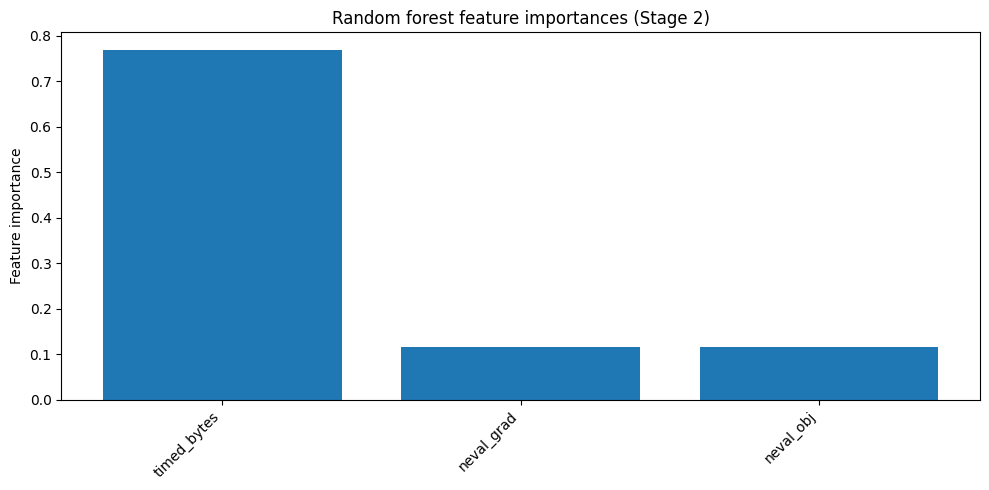

In [187]:
best_model_time_raw = time_best_model_raw
rf_importances = best_model_time_raw.feature_importances_
indices_rf = np.argsort(rf_importances)[::-1]  

plt.figure(figsize=(10, 5))
plt.bar(range(len(target_cols_reg)), rf_importances[indices_rf])
plt.xticks(range(len(target_cols_reg)), [target_cols_reg[i] for i in indices_rf], rotation=45, ha="right")
plt.ylabel("Feature importance")
plt.title("Random forest feature importances (Stage 2)")
plt.tight_layout()
plt.show()